In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from  matplotlib.colors import LinearSegmentedColormap

# countries=['Belgium', 'Great Britain', 'Ireland', 'Germany', 'France', 'Finland', 'Sweden']

# def get_CI_seq(_dfs, country):
#         """
#         Returns array of CI values of country between start_date and end_date.
#         Start_date and end_date are datetime objects.
#         Country is a string.
#         """
#         df_to_plot = _dfs[country][
#             _dfs[country]["datetime"].between(self.start_time, self.end_time)
#         ]
#         return df_to_plot["CI_direct"].values

# def plot_mean_CI(av_mat):
#     """
#     Display the mean CI value for each country in between these two dates, and the global mean over all countries.
#     """

#     mean_list = []
#     for country in countries:
#         CI_values = self.get_CI_seq(country)
#         mean_list.append(CI_values.mean())
#     # dict_countries_CI = dict(zip(self.countries, mean_list))

#     fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
#     plt.plot(self.countries, mean_list, "o")
#     plt.title("Mean CI over the chosen period")
#     plt.ylabel("CI (gCO2eq/kWh)")
#     plt.xticks(rotation=45, ha="right")  # rotate x-axis labels to diagonal
#     plt.grid()

#     global_mean_CI = np.array(mean_list).mean()
#     ax.axhline(y=global_mean_CI, color="r", linestyle="-", label="mean CI")
#     median_CI = np.median(np.array(mean_list))
#     ax.axhline(y=median_CI, color="g", linestyle="-", label="median CI")
#     ax.legend()
#     plt.savefig(self.out_folder + "/means.png", bbox_inches="tight")
#     plt.show()

def plot_av_mat(av_mat_name, folder, av_mat_folder=""):
    """
    Plot heatmap of availability matrix (countries x datetime list).
    Green: available, Red: not available.
    """

    if len(av_mat_folder)>0:
        _path = "../availability_matrices/"+av_mat_folder+"/av-mat_"+av_mat_name+".csv"
    else:
        _path = "../availability_matrices/av-mat_"+av_mat_name+".csv"

    df = pd.DataFrame(pd.read_csv(_path, index_col=[0]))
    df.columns=[i for i in range(df.shape[1])]
    df.rename(index={'Belgium': 'Bel.', 'Great Britain': 'G. B.', 'Ireland': 'Ire.', 'Germany':'Ger.', 'France':'Fra.', 'Finland':'Fin.', 'Sweden':'Swe.'}, inplace=True)

    print(df.sum().sum())
    plt.figure(figsize=(4, 2))
    ax = plt.subplot()

    cmap = LinearSegmentedColormap.from_list("rwg", ["darkred", "limegreen"], N=2)
    sns.heatmap(df.astype(int), annot=False, fmt='d', cbar=False, cmap=cmap, linewidths=0.5, linecolor='white', ax=ax) # create heatmap

    if not isinstance(df.columns[0], np.int64):
        plt.xticks(rotation=45, ha='right')  # rotate x-axis labels to diagonal
    xticks = ax.get_xticks()
    xticks = xticks[::2]
    ax.set_xticks(xticks) # set new xticks

    # plt.title(av_mat_name)
    # plt.title("alpha 1.0")

    plt.savefig('figures/'+folder+'/'+av_mat_name+'.png', bbox_inches='tight')
    plt.show()

    
def plot_av_mat2(av_mat_name, folder, av_mat_folder=""):
    """
    Plot heatmap of availability matrix (countries x datetime list).
    Green: available, Red: not available.
    """

    if len(av_mat_folder)>0:
        _path = "../availability_matrices/"+av_mat_folder+"/av-mat_"+av_mat_name+".csv"
    else:
        _path = "../availability_matrices/av-mat_"+av_mat_name+".csv"

    df = pd.DataFrame(pd.read_csv(_path, index_col=[0]))
    df.columns=[i for i in range(df.shape[1])]

    print(df.sum().sum())
    plt.figure(figsize=(4, 2))
    ax = plt.subplot()

    cmap = LinearSegmentedColormap.from_list("rwg", ["darkred", "limegreen"], N=2)
    sns.heatmap(df.astype(int), annot=False, fmt='d', cbar=False, cmap=cmap, linewidths=0.5, linecolor='white', ax=ax) # create heatmap

    if not isinstance(df.columns[0], np.int64):
        plt.xticks(rotation=45, ha='right')  # rotate x-axis labels to diagonal
    xticks = ax.get_xticks()
    xticks = xticks[::2]
    ax.set_xticks(xticks) # set new xticks
    ax.set_yticks([]) # set new xticks

    # plt.title(av_mat_name)
    # plt.title("alpha 0.1")
    plt.savefig('figures/'+folder+'/'+av_mat_name+'.png', bbox_inches='tight')
    plt.show()

def plot_stats(av_mat_name, folder, av_mat_folder=""):
    """
    Plot heatmap of availability matrix (countries x datetime list).
    Green: available, Red: not available.
    """

    if len(av_mat_folder)>0:
        _path = "../availability_matrices/"+av_mat_folder+"/av-mat_"+av_mat_name+".csv"
    else:
        _path = "../availability_matrices/av-mat_"+av_mat_name+".csv"

    df = pd.DataFrame(pd.read_csv(_path, index_col=[0]))
    df.columns=[i for i in range(df.shape[1])]

    display(df)
    display(df.loc[['Germany', 'Ireland', 'Finland']].sum().sum())
    display(df.loc[['Belgium', 'France', 'Great Britain', 'Sweden']].sum().sum())

    

In [93]:
folder='alphaF_eval/av_mat'
plot_stats("alphaF50-alpha0.1-8cb", folder, av_mat_folder="")

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
Belgium,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,1,1
Ireland,1,1,1,0,0,0,0,0,0,0,...,1,1,1,1,0,0,0,0,0,0
Germany,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
France,1,0,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Great Britain,0,0,0,0,1,1,1,1,1,1,...,0,0,0,0,1,1,1,1,1,1
Finland,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
Sweden,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


24

144

191


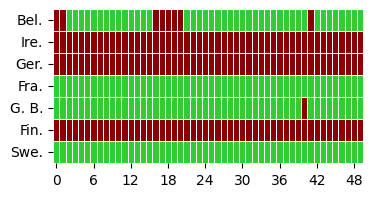

168


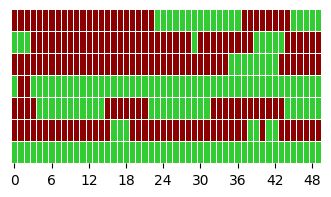

In [94]:
av_mat_list = [
"alphaF50-alpha1.0-8cb",
"alphaF50-alpha0.1-8cb"
]
folder='alphaF_eval/av_mat'
for av_mat_name in [av_mat_list[0]]:
    plot_av_mat(av_mat_name, folder)
for av_mat_name in [av_mat_list[1]]:
    plot_av_mat2(av_mat_name, folder)